In [1]:
import pandas as pd
import os
import sqlalchemy
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
category_df = pd.read_csv("C:/Users/vince/Desktop/apple/apple/category.csv", sep=',', encoding='latin1')
products_df = pd.read_csv("C:/Users/vince/Desktop/apple/apple/products.csv", sep=',', encoding='latin1')
sales_df = pd.read_csv("C:/Users/vince/Desktop/apple/apple/sales.csv", sep=',', encoding='latin1')
stores_df = pd.read_csv("C:/Users/vince/Desktop/apple/apple/stores.csv", sep=',', encoding='latin1')
warranty_df = pd.read_csv("C:/Users/vince/Desktop/apple/apple/warranty.csv", sep=',', encoding='latin1')


In [3]:
print(category_df.head())
print(products_df.head())
print(sales_df.head())
print(stores_df.head())
print(warranty_df.head())

  category_id category_name
0       CAT-1        Laptop
1       CAT-2         Audio
2       CAT-3        Tablet
3       CAT-4    Smartphone
4       CAT-5      Wearable
  Product_ID         Product_Name Category_ID Launch_Date  Price
0        P-1              MacBook       CAT-1  2023-09-17   1149
1        P-2     MacBook Air (M1)       CAT-1  2023-11-11   1783
2        P-3     MacBook Air (M2)       CAT-1  2020-05-24   1588
3        P-4  MacBook Pro 13-inch       CAT-1  2021-01-17   1351
4        P-5  MacBook Pro 14-inch       CAT-1  2024-05-12    768
     sale_id   sale_date store_id product_id  quantity
0    YG-8782  16-06-2023    ST-10       P-38        10
1  QX-999001  13-04-2022    ST-63       P-48        10
2   JG-46890  05-07-2021    ST-26       P-79         5
3    XJ-1731  20-07-2022    ST-15       P-24         9
4   FG-95080  18-03-2022    ST-35       P-69         7
  Store_ID             Store_Name           City        Country
0     ST-1     Apple Fifth Avenue       New York

In [4]:
print(category_df.info())
print(products_df.info())
print(sales_df.info())
print(stores_df.info())
print(warranty_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   category_id    10 non-null     object
 1   category_name  10 non-null     object
dtypes: object(2)
memory usage: 292.0+ bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Product_ID    89 non-null     object
 1   Product_Name  89 non-null     object
 2   Category_ID   89 non-null     object
 3   Launch_Date   89 non-null     object
 4   Price         89 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 3.6+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040200 entries, 0 to 1040199
Data columns (total 5 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   sale_id     1040200 non-n

In [5]:
print(category_df.isnull().sum())


category_id      0
category_name    0
dtype: int64


In [6]:
print(products_df.isnull().sum())


Product_ID      0
Product_Name    0
Category_ID     0
Launch_Date     0
Price           0
dtype: int64


In [7]:
print(sales_df.isnull().sum())


sale_id       0
sale_date     0
store_id      0
product_id    0
quantity      0
dtype: int64


In [8]:
print(stores_df.isnull().sum())


Store_ID      0
Store_Name    0
City          0
Country       0
dtype: int64


In [9]:
print(warranty_df.isnull().sum())

claim_id         0
claim_date       0
sale_id          0
repair_status    0
dtype: int64


In [10]:
print(category_df.duplicated().sum())
print(products_df.duplicated().sum())
print(sales_df.duplicated().sum())
print(stores_df.duplicated().sum())
print(warranty_df.duplicated().sum())

0
0
0
0
0


In [11]:
print("products_df shape:", products_df.shape)
print("sales_df shape:", sales_df.shape)
print("warranty_df shape:", warranty_df.shape)
print("stores_df shape:", stores_df.shape)
print("category_df shape:", category_df.shape)

products_df shape: (89, 5)
sales_df shape: (1040200, 5)
warranty_df shape: (30000, 4)
stores_df shape: (75, 4)
category_df shape: (10, 2)


In [12]:
print("Warranty columns:", warranty_df.columns.tolist())
print("Sales columns:", sales_df.columns.tolist())
print("Products columns:", products_df.columns.tolist())
print("Stores columns:", stores_df.columns.tolist())
print("Category columns:", category_df.columns.tolist())

Warranty columns: ['claim_id', 'claim_date', 'sale_id', 'repair_status']
Sales columns: ['sale_id', 'sale_date', 'store_id', 'product_id', 'quantity']
Products columns: ['Product_ID', 'Product_Name', 'Category_ID', 'Launch_Date', 'Price']
Stores columns: ['Store_ID', 'Store_Name', 'City', 'Country']
Category columns: ['category_id', 'category_name']


In [13]:
dfs = [sales_df, products_df, stores_df, category_df, warranty_df]

for df in dfs:
    df.columns = df.columns.str.lower()

In [14]:
print("Warranty columns:", warranty_df.columns.tolist())
print("Sales columns:", sales_df.columns.tolist())
print("Products columns:", products_df.columns.tolist())
print("Stores columns:", stores_df.columns.tolist())
print("Category columns:", category_df.columns.tolist())

Warranty columns: ['claim_id', 'claim_date', 'sale_id', 'repair_status']
Sales columns: ['sale_id', 'sale_date', 'store_id', 'product_id', 'quantity']
Products columns: ['product_id', 'product_name', 'category_id', 'launch_date', 'price']
Stores columns: ['store_id', 'store_name', 'city', 'country']
Category columns: ['category_id', 'category_name']


In [15]:
category_df.describe()


,category_id,category_name
count,10,10
unique,10,10
top,CAT-1,Laptop
freq,1,1


In [16]:
products_df.describe()


,price
count,89.000000
mean,1078.078652
std,501.628059
min,231.000000
25%,623.000000
50%,1149.000000
75%,1436.000000
max,1965.000000


In [17]:
sales_df.describe()


,quantity
count,1.040200e+06
mean,5.500235e+00
std,2.874295e+00
min,1.000000e+00
25%,3.000000e+00
50%,5.000000e+00
75%,8.000000e+00
max,1.000000e+01


In [18]:
stores_df.describe()


,store_id,store_name,city,country
count,75,75,75,75
unique,75,69,47,19
top,ST-1,Apple Champs-Elysees,London,United States
freq,1,2,4,15


In [19]:
warranty_df.describe()

,claim_id,claim_date,sale_id,repair_status
count,30000,30000,30000,30000
unique,30000,317,30000,4
top,CL-58750,2024-04-08,YG-8782,In Progress
freq,1,127,1,7611


In [20]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [21]:
#facciamo una merge unica per avere un dataset completo ed avere una visione unica del progetto
apple_df_merged = (
    sales_df
    .merge(warranty_df, on='sale_id', how='left')
    .merge(products_df, on='product_id', how='left')
    .merge(stores_df, on='store_id', how='left')
    .merge(category_df, on='category_id', how='left')
)

In [22]:
apple_df_merged.head()

,sale_id,sale_date,store_id,product_id,quantity,claim_id,claim_date,repair_status,product_name,category_id,launch_date,price,store_name,city,country,category_name
0,YG-8782,16-06-2023,ST-10,P-38,10,CL-58750,2024-01-30,Completed,iPhone 13 Pro,CAT-4,2021-03-22,308,Apple South Coast Plaza,Costa Mesa,United States,Smartphone
1,QX-999001,13-04-2022,ST-63,P-48,10,CL-8874,2024-06-25,Pending,Apple Watch Nike Edition,CAT-5,2020-06-24,884,Apple Parque La Colina,Bogota,Colombia,Wearable
2,JG-46890,05-07-2021,ST-26,P-79,5,CL-14486,2024-08-13,Pending,Magic Trackpad,CAT-10,2024-05-25,1242,Apple Leidseplein,Amsterdam,Netherlands,Accessories
3,XJ-1731,20-07-2022,ST-15,P-24,9,CL-42187,2024-09-19,Pending,iPad mini (6th Generation),CAT-3,2022-11-27,573,Apple Downtown Brooklyn,Brooklyn,United States,Tablet
4,FG-95080,18-03-2022,ST-35,P-69,7,CL-37590,2024-09-16,Completed,Apple TV+,CAT-8,2024-11-04,404,Apple Shanghai IFC,Shanghai,China,Subscription Service


In [23]:
#controllo se ci sono dati nulli


apple_df_merged.isnull().sum()

sale_id                0
sale_date              0
store_id               0
product_id             0
quantity               0
claim_id         1010200
claim_date       1010200
repair_status    1010200
product_name           0
category_id            0
launch_date            0
price                  0
store_name             0
city                   0
country                0
category_name          0
dtype: int64

In [24]:
#vedo come è composto il dataset
apple_df_merged.shape


(1040200, 16)

In [25]:
# sostituisco i dati nulli della tabella claim con "No claim" per non avere campi vuoti ed analizzare quanti prodotti non hanno subito reclami 
apple_df_merged['claim_id'] = apple_df_merged['claim_id'].fillna(0)
apple_df_merged['claim_date'] = apple_df_merged['claim_date'].fillna('No claim')
apple_df_merged['repair_status'] = apple_df_merged['repair_status'].fillna('No claim')

In [26]:
apple_df_merged.isnull().sum()

sale_id          0
sale_date        0
store_id         0
product_id       0
quantity         0
claim_id         0
claim_date       0
repair_status    0
product_name     0
category_id      0
launch_date      0
price            0
store_name       0
city             0
country          0
category_name    0
dtype: int64

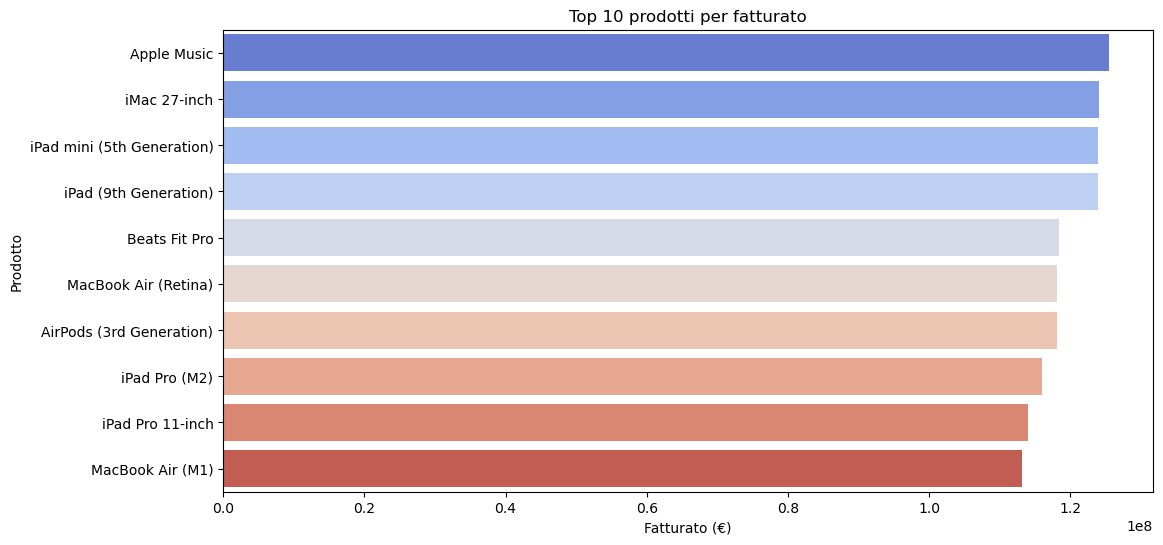

In [27]:
# Creiamo la colonna fatturato
apple_df_merged['revenue'] = apple_df_merged['quantity'] * apple_df_merged['price']

# Top 10 prodotti per fatturato
top_products = apple_df_merged.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(10)

#Mostriamo graficamente il risultato 

plt.figure(figsize=(12,6))
sns.barplot(x=top_products.values, y=top_products.index, palette='coolwarm')
plt.title('Top 10 prodotti per fatturato')
plt.xlabel('Fatturato (€)')
plt.ylabel('Prodotto')
plt.show()

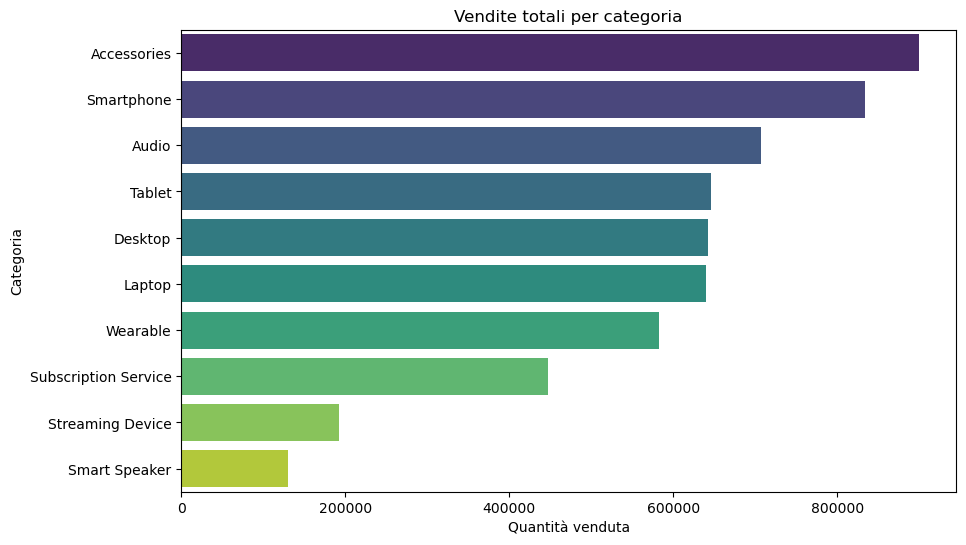

In [28]:
#vendite totali per categoria
category_sales = apple_df_merged.groupby('category_name')['quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=category_sales.values, y=category_sales.index, palette='viridis')
plt.title('Vendite totali per categoria')
plt.xlabel('Quantità venduta')
plt.ylabel('Categoria')
plt.show()

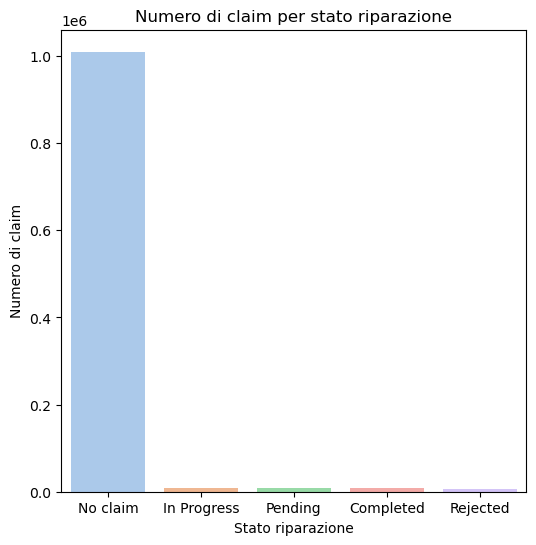

In [29]:
#Numero di claim per stato riparazione
repair_counts = apple_df_merged['repair_status'].value_counts()

plt.figure(figsize=(6,6))
sns.barplot(x=repair_counts.index, y=repair_counts.values, palette='pastel')
plt.title('Numero di claim per stato riparazione')
plt.xlabel('Stato riparazione')
plt.ylabel('Numero di claim')
plt.show()

In [30]:
#in questo caso vediamo come la maggior parte dei prodotti non abbia ricevuto alcun reclamo


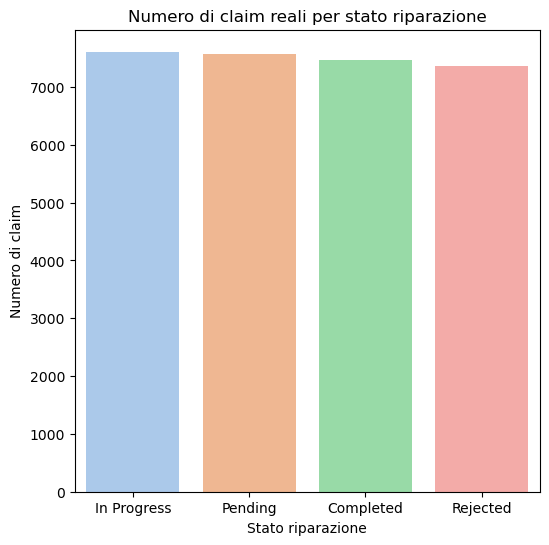

In [31]:
# Filtriamo solo i claim reali in modo da avere un grafico piu omogeneo
real_claims = apple_df_merged[apple_df_merged['repair_status'] != 'No claim']

# Conta dei claim per stato
repair_counts = real_claims['repair_status'].value_counts()

plt.figure(figsize=(6,6))
sns.barplot(x=repair_counts.index, y=repair_counts.values, palette='pastel')
plt.title('Numero di claim reali per stato riparazione')
plt.xlabel('Stato riparazione')
plt.ylabel('Numero di claim')
plt.show()

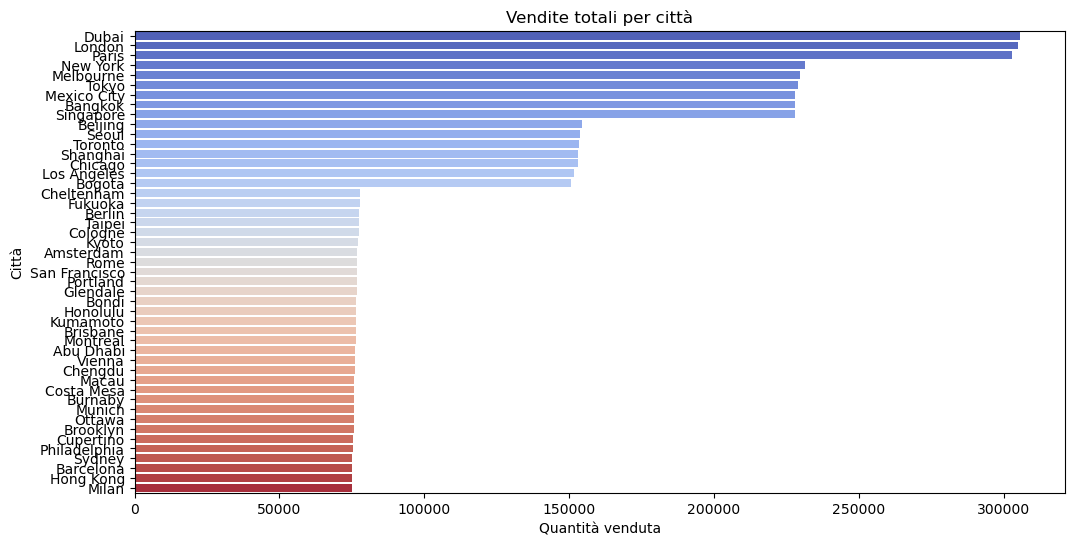

In [32]:
#Vendite per città
city_sales = apple_df_merged.groupby('city')['quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=city_sales.values, y=city_sales.index, palette='coolwarm')
plt.title('Vendite totali per città')
plt.xlabel('Quantità venduta')
plt.ylabel('Città')
plt.show()

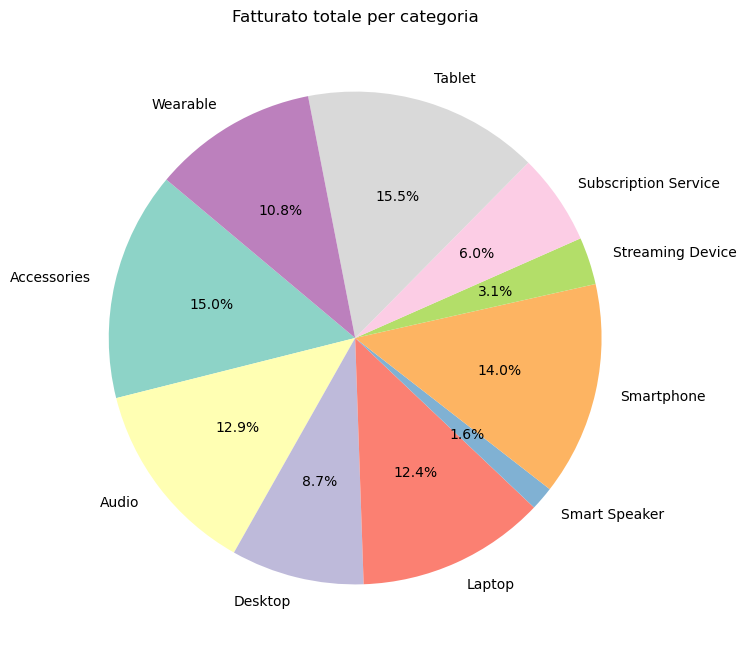

In [33]:
#Fatturato totale per categoria

category_revenue = apple_df_merged.groupby('category_name')['revenue'].sum()

plt.figure(figsize=(8,8))
plt.pie(category_revenue, labels=category_revenue.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set3', len(category_revenue)))
plt.title('Fatturato totale per categoria')
plt.show()

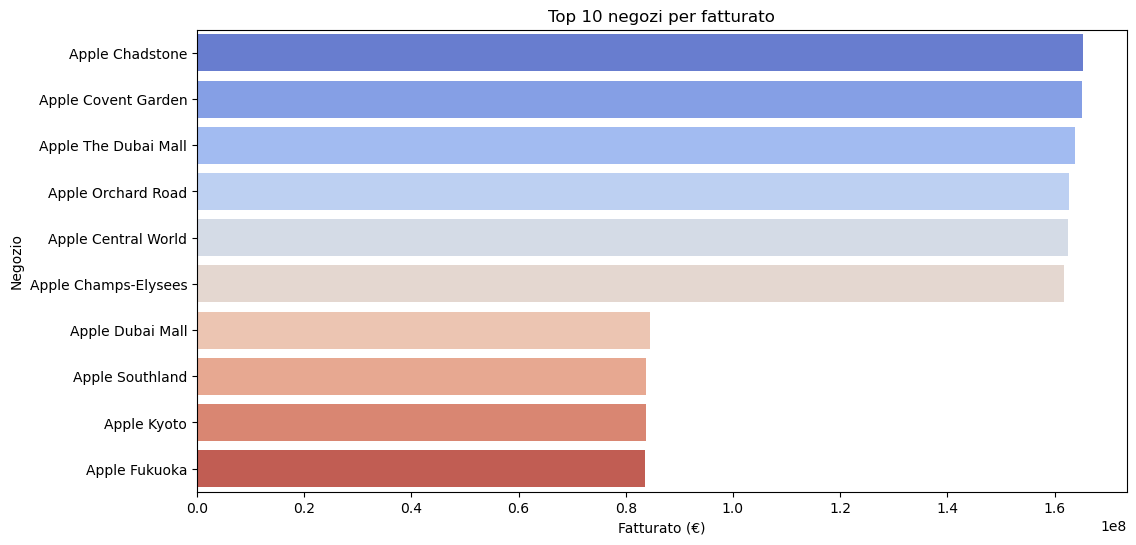

In [34]:
#Top 10 negozi per fatturato
store_revenue = apple_df_merged.groupby('store_name')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=store_revenue.values, y=store_revenue.index, palette='coolwarm')
plt.title('Top 10 negozi per fatturato')
plt.xlabel('Fatturato (€)')
plt.ylabel('Negozio')
plt.show()

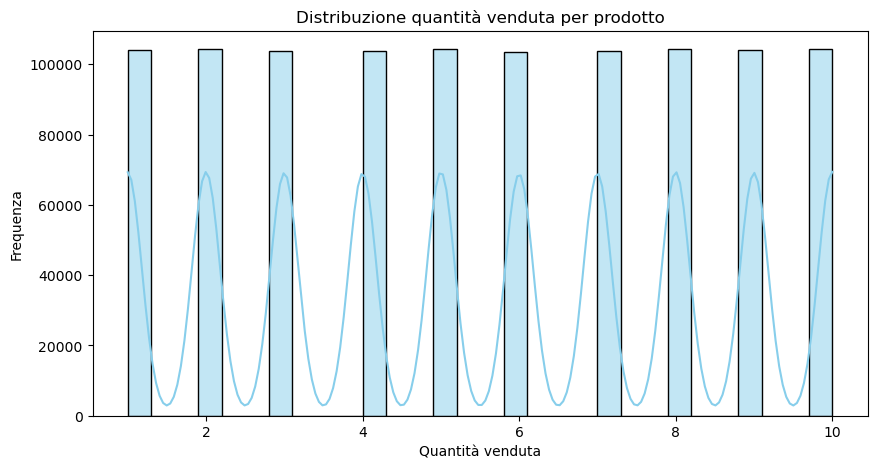

In [35]:
#Quantità venduta per prodotto
plt.figure(figsize=(10,5))
sns.histplot(apple_df_merged['quantity'], bins=30, kde=True, color='skyblue')
plt.title('Distribuzione quantità venduta per prodotto')
plt.xlabel('Quantità venduta')
plt.ylabel('Frequenza')
plt.show()

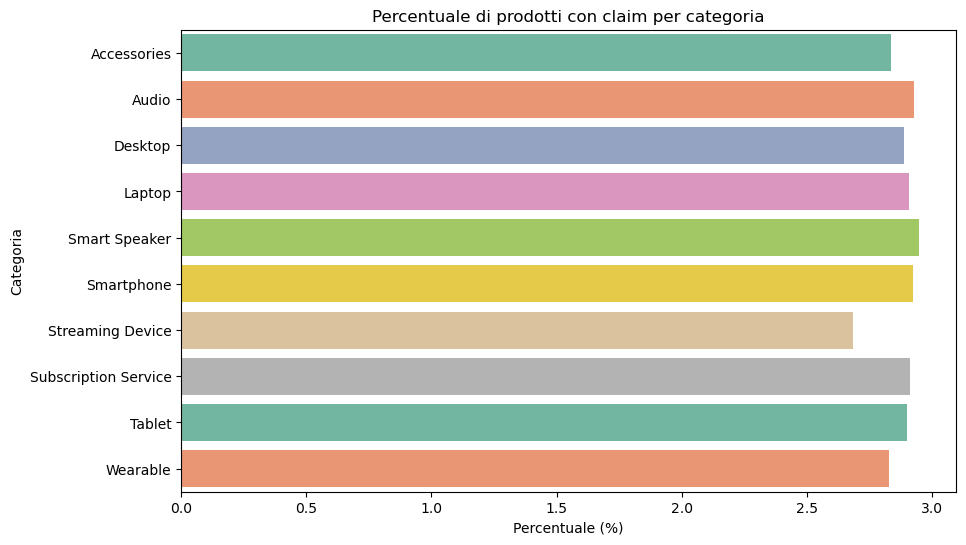

In [36]:
#Percentuale di prodotti con claim per categoria
apple_df_merged['has_claim'] = apple_df_merged['repair_status'] != 'No claim'

claim_by_category = apple_df_merged.groupby('category_name')['has_claim'].mean() * 100

plt.figure(figsize=(10,6))
sns.barplot(x=claim_by_category.values, y=claim_by_category.index, palette='Set2')
plt.title('Percentuale di prodotti con claim per categoria')
plt.xlabel('Percentuale (%)')
plt.ylabel('Categoria')
plt.show()

In [37]:
print("In questo progetto abbiamo esplorato le vendite, i prodotti, le categorie e le richieste di warranty, analizzando trend, top prodotti e performance dei negozi. Abbiamo trasformato dati grezzi in insight chiari, in grado di guidare decisioni strategiche e ottimizzare l’esperienza del cliente.‘Think Different.’ Anche nel mondo dei dati, innovare significa guardare oltre i numeri e creare valore reale.")

In questo progetto abbiamo esplorato le vendite, i prodotti, le categorie e le richieste di warranty, analizzando trend, top prodotti e performance dei negozi. Abbiamo trasformato dati grezzi in insight chiari, in grado di guidare decisioni strategiche e ottimizzare l’esperienza del cliente.‘Think Different.’ Anche nel mondo dei dati, innovare significa guardare oltre i numeri e creare valore reale.
